# Plaquette number distributions in the 4x7 ground state

In [ ]:
import os
import sys
import logging
import math
from pathlib import Path
import subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.sharding import NamedSharding, PartitionSpec, AxisType
from jax.experimental.sparse.linalg import lobpcg_standard
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.ground_locg import ground_locg
from skqd_z2lgt.sqd import get_hamiltonian_arrays, sqd
from skqd_z2lgt.ising_dmrg import ising_dmrg
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from ising_hamiltonian import make_apply_h

os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.99'
jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO)

python = '/home/iiyama/src/qii-miyabi-kawasaki/.venv/bin/python'
data_dir = Path('/data/iiyama/2dz2/buildup')

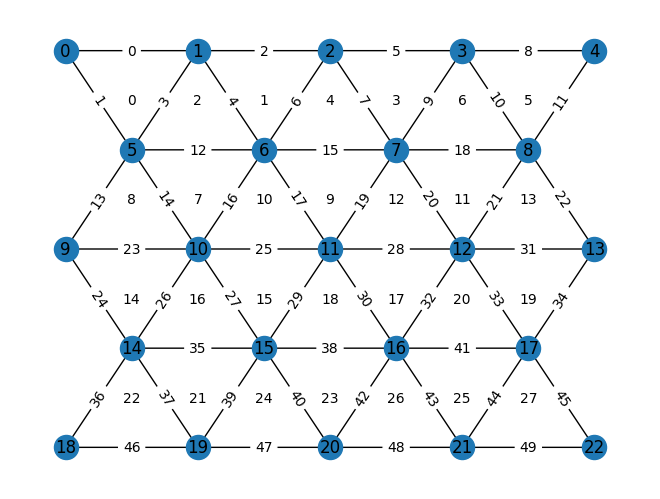

In [2]:
nrow, ncol = 4, 7
num_qubits = nrow * ncol
lattice = TriangularZ2Lattice((nrow, ncol))
lattice.draw_graph();

In [3]:
nsites = (ncol - 1) // 2 + 1 + (nrow // 2 + 1) % 2
vfirst = (lattice.num_vertices - nsites) // 2
links = []
for ivtx in range(vfirst, vfirst + nsites - 1):
    links.append(lattice.graph.edge_indices_from_endpoints(ivtx, ivtx + 1)[0])
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][links] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)

In [4]:
vdim = 2 ** num_qubits

@jax.jit
def weighted_histogram(eigvec):
    probs = jnp.square(eigvec)
    table = jnp.zeros((vdim, num_qubits + 1))
    indices = jnp.arange(vdim)
    nexcs = jnp.bitwise_count(indices)
    table = table.at[indices, nexcs].set(probs)
    return jnp.sum(table, axis=0)

plaq_es = np.linspace(1., 2., 5)

eigvals = []
probs = []
distributions = []
for plaq_e in plaq_es:
    hamiltonian = dual_lattice.make_hamiltonian(plaq_e)
    apply_h = make_apply_h(hamiltonian)
    eigval, eigvec, iter = ground_locg(apply_h, 0, vspace=(vdim, np.float64))
    eigvals.append(float(eigval))
    probs.append(np.array(jnp.square(eigvec)))
    distributions.append(np.array(weighted_histogram(eigvec)))

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
W0326 01:59:53.046488  408462 hlo_rematerialization.cc:3233] Can't reduce memory use below 72.63GiB (77991575154 bytes) by rematerialization; only reduced to 116.00GiB (124554051816 bytes), down from 116.00GiB (124554051816 bytes) originally


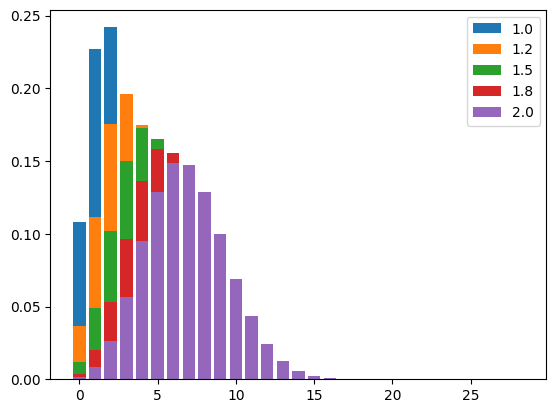

In [5]:
for plaq_e, hist in zip(plaq_es, distributions):
    plt.bar(np.linspace(0., num_qubits, num_qubits + 1), hist, label=f'{plaq_e:.1f}')

plt.legend();

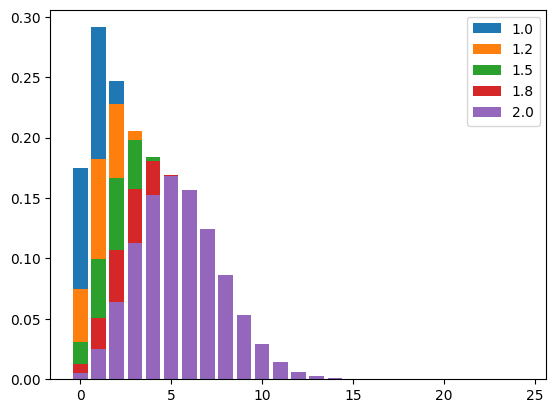

In [8]:
for plaq_e, hist in zip(plaq_es, distributions):
    plt.bar(np.linspace(0., num_qubits, num_qubits + 1), hist, label=f'{plaq_e:.1f}')

plt.legend();

In [12]:
hamiltonian = dual_lattice.make_hamiltonian(2.)
apply_h = make_apply_h(hamiltonian)
eigval, eigvec, iter = ground_locg(apply_h, 0, vspace=(vdim, np.float64))

In [13]:
probs = jnp.square(eigvec)
sort_idx = jnp.argsort(probs)[::-1]

In [14]:
for idx, prob in zip(np.array(sort_idx[:100]), np.array(probs[sort_idx])):
    print(np.nonzero((idx >> np.arange(num_qubits)) % 2)[0], prob)

[] 0.005014059684685628
[9] 0.00245036580280118
[13] 0.0024503658028011775
[11] 0.0023194215086262725
[15] 0.002319421508626264
[7] 0.0019920776827060753
[12] 0.001992077682706068
[ 8  9 11] 0.001459295836803331
[13 15 16] 0.0014592958368033304
[ 9 11] 0.0012458716827086049
[13 15] 0.001245871682708603
[6 7 9] 0.001166060706499501
[12 13 14] 0.0011660607064995006
[ 9 15] 0.0011001232614263263
[11 13] 0.0011001232614263263
[12 13] 0.0010618599142920581
[7 9] 0.0010618599142920562
[8 9] 0.0010616482889307436
[13 16] 0.0010616482889307369
[13 14] 0.0010117315013949328
[6 9] 0.001011731501394932
[ 8 11] 0.0010012144430753636
[15 16] 0.0010012144430753623
[ 7 13] 0.000949332375169039
[ 9 12] 0.0009493323751690387
[12 15] 0.0009263034740100638
[ 7 11] 0.0009263034740100631
[11 12] 0.0009186321172404792
[ 7 15] 0.0009186321172404778
[8] 0.0008540705073259401
[16] 0.0008540705073259391
[12 13 14 15 16] 0.0008315245461179544
[ 6  7  8  9 11] 0.0008315245461179537
[6] 0.0008214141134391806
[14] 